In [15]:
import torch
import torch.nn as nn
import numpy as np
import time
import matplotlib.pyplot as plt
from matplotlib import cm
from collections import OrderedDict

In [16]:
# Set random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [17]:
Lx = 1.0     # Spatial domain: x in [0, Lx]
Ly = 1.0     # Spatial domain: y in [0, Ly]
T = 1.0      # Temporal domain: t in [0, T] 
c = 1.0      # Wave speed

n_collocation = 5000  # Number of collocation points inside domain
n_boundary    = 500   # Number of points for boundary conditions (each boundary)
n_initial     = 1000  # Number of points for initial conditions
hidden_layers = 6     # Number of hidden layers
neurons       = 50    # Neurons per hidden layer
learning_rate = 1e-3  # Learning rate for optimizer
num_epochs    = 10000 # Training epochs

In [18]:
class DNN(torch.nn.Module):
    def __init__(self, layers):
        super(DNN, self).__init__()

        # parameters
        self.depth = len(layers) - 1

        # set up layer order dict
        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i + 1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)

        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        out = self.layers(x)
        return out

class sampling_MMPDE_2D():
    def __init__(self, X_f, u_fun, layers, lb, ub, nu, AdamIter, LBFGSIter):
        self.lb = torch.tensor(lb).float().to(device)
        self.ub = torch.tensor(ub).float().to(device)

        self.t_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float().to(device)
        self.x_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float().to(device)
        self.y_f = torch.tensor(X_f[:, 2:3], requires_grad=True).float().to(device)
        self.fun = u_fun

        self.layers = layers
        self.nu = nu

        self.dnn = DNN(layers).to(device)

        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters(),
                                              lr=1e-3,
                                              betas=(0.9, 0.999),
                                              eps=1e-8)
        
        self.AdamIter = AdamIter

        self.optimizer_LBFGS = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=0.5,
            max_iter=LBFGSIter,
        )

        self.optimizer = None
        self.loss = None
        self.iter = 0
        self.start_time = None

    def detach(self, data):
        return data.detach().cpu().numpy()

    def monitor(self, t, x, y):

        t.requires_grad_(True)
        x.requires_grad_(True) 
        y.requires_grad_(True)

        inputs = torch.cat([t, x, y], dim=1)
        uv = self.fun(inputs)
        u = uv[:, [0]]  
        v = uv[:, [1]]  

        u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True,
            allow_unused=True
        )[0]
        
        u_y = torch.autograd.grad(
            u, y,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True,
            allow_unused=True
        )[0]

        v_t = torch.autograd.grad(
            v, t,
            grad_outputs=torch.ones_like(v),
            retain_graph=True,
            create_graph=True,
            allow_unused=True
        )[0]

        if u_x is None:
            u_x = torch.zeros_like(u)
        if u_y is None:
            u_y = torch.zeros_like(u)
        if v_t is None:
            v_t = torch.zeros_like(v)

        w = (1 + (u_x)**2 + (u_y)**2 + 0.1 * (v_t)**2) ** (1/2)
        
        return w

    def net_sample(self, t, x, y):
        inputs = torch.cat([t, x, y], dim=1)
        xy_new = self.dnn(inputs)

        x_new = xy_new[:, [0]]
        y_new = xy_new[:, [1]]

        gx0 = x - self.lb[1] 
        gx1 = x - self.ub[1] 
        gy0 = y - self.lb[2] 
        gy1 = y - self.ub[2]

        x_new = gx0 * gx1 * x_new + x
        y_new = gy0 * gy1 * y_new + y
        
        return x_new, y_new

    def net_f(self, t, x, y):
        x_new, y_new = self.net_sample(t, x, y)

        x_new_t = torch.autograd.grad(
            x_new, t,
            grad_outputs=torch.ones_like(x_new),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_t = torch.autograd.grad(
            y_new, t,
            grad_outputs=torch.ones_like(y_new),
            retain_graph=True,
            create_graph=True
        )[0]

        x_new_x = torch.autograd.grad(
            x_new, x,
            grad_outputs=torch.ones_like(x_new),
            retain_graph=True,
            create_graph=True
        )[0]

        x_new_y = torch.autograd.grad(
            x_new, y,
            grad_outputs=torch.ones_like(x_new),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_x = torch.autograd.grad(
            y_new, x,
            grad_outputs=torch.ones_like(y_new),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_y = torch.autograd.grad(
            y_new, y,
            grad_outputs=torch.ones_like(y_new),
            retain_graph=True,
            create_graph=True
        )[0]

        x_new_xx = torch.autograd.grad(
            x_new_x, x,
            grad_outputs=torch.ones_like(x_new_x),
            retain_graph=True,
            create_graph=True
        )[0]

        x_new_yy = torch.autograd.grad(
            x_new_y, y,
            grad_outputs=torch.ones_like(x_new_y),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_xx = torch.autograd.grad(
            y_new_x, x,
            grad_outputs=torch.ones_like(y_new_x),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_yy = torch.autograd.grad(
            y_new_y, y,
            grad_outputs=torch.ones_like(y_new_y),
            retain_graph=True,
            create_graph=True
        )[0]

        G = self.monitor(t, x, y)

        G_t = torch.autograd.grad(
            G, t,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        G_x = torch.autograd.grad(
            G, x,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        G_y = torch.autograd.grad(
            G, y,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        # For x coordinate:
        E_x = G_x * x_new_x + G_y * x_new_y + G * (x_new_xx + x_new_yy)
        f_x = x_new_t * self.nu * (G**2) * (x_new_x**2 + x_new_y**2) + E_x

        # For y coordinate:
        E_y = G_x * y_new_x + G_y * y_new_y + G * (y_new_xx + y_new_yy)
        f_y = y_new_t * self.nu * (G**2) * (y_new_x**2 + y_new_y**2) + E_y

        return f_x, f_y

    def loss_func(self):
        f_x, f_y = self.net_f(self.t_f, self.x_f, self.y_f)
        loss_f = torch.mean(f_x ** 2) + torch.mean(f_y ** 2)
        
        return loss_f

    def optimize_one_epoch(self):
        if self.start_time is None:
            self.start_time = time.time()

        self.optimizer.zero_grad()
        self.loss = self.loss_func()
        self.loss.backward()
        self.iter = self.iter + 1

        if self.iter % 100 == 0:
            loss = self.detach(self.loss)
            print(f"{self.optimizer_name} Iter {self.iter}, Loss: {loss:.6f}")
            elapsed = time.time() - self.start_time
            print(f'Time: {elapsed:.4f}s')
            self.start_time = time.time()

        return self.loss

    def train_Adam(self, optimizer, nIter):
        self.optimizer = optimizer
        self.optimizer_name = '2D_EMMPDE_Adam'
        
        for it in range(nIter):
            self.optimize_one_epoch()
            self.optimizer.step()

    def train_LBFGS(self, optimizer):
        self.optimizer = optimizer
        self.optimizer_name = '2D_EMMPDE_LBFGS'

        def closure():
            loss = self.optimize_one_epoch()
            return loss

        self.optimizer.step(closure)

    def train(self):
        print("开始2D MMPDE训练...")
        self.train_Adam(self.optimizer_Adam, self.AdamIter)
        print("2D MMPDE_Adam 完成!")
        self.train_LBFGS(self.optimizer_LBFGS)
        print('2D MMPDE_LBGFS 完成!')

        # 返回新的采样点
        x_new, y_new = self.net_sample(self.t_f, self.x_f, self.y_f)
        new_sample = torch.cat([self.t_f, x_new, y_new], dim=1)
        return new_sample

In [19]:
class PINN(nn.Module):
    def __init__(self, layers, activation=nn.Tanh()):
        super(PINN, self).__init__()
        
        self.linears = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        
        self.activation = activation

        for m in self.linears:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
    
    def forward(self, x):
        for i in range(len(self.linears) - 1):
            x = self.activation(self.linears[i](x))
            
        x = self.linears[-1](x)
        return x

In [20]:
def f1(x, y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)

def f2(x, y):
    return np.zeros_like(x)

def boundary_condition_u(t, x, y):
    return np.zeros_like(t)

def boundary_condition_v(t, x, y):
    return np.zeros_like(t)

In [21]:
def exact_solution_u(x, y, t, c=1.0):
    omega = np.pi * c * np.sqrt(2)  # Frequency for the (1,1) mode
    return np.sin(np.pi * x) * np.sin(np.pi * y) * np.cos(omega * t)

def exact_solution_v(x, y, t, c=1.0):
    omega = np.pi * c * np.sqrt(2)  # Frequency for the (1,1) mode
    return -omega * np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(omega * t)

def exact_solution_uv(x, y, t, c=1.0):
    u = exact_solution_u(x, y, t, c)
    v = exact_solution_v(x, y, t, c)
    return np.column_stack((u.flatten(), v.flatten()))


In [22]:
def wave_pde_loss(model, t, x, y):
    t.requires_grad_(True)
    x.requires_grad_(True)
    y.requires_grad_(True)

    inputs = torch.cat((t, x, y), dim=1)
    uv = model(inputs)
    u = uv[:, [0]] 
    v = uv[:, [1]]  

    u_grads = torch.autograd.grad(u, inputs, 
                                 grad_outputs=torch.ones_like(u), 
                                 create_graph=True)[0]
    u_t = u_grads[:, [0]]
    u_x = u_grads[:, [1]]
    u_y = u_grads[:, [2]]

    v_grads = torch.autograd.grad(v, inputs,
                                 grad_outputs=torch.ones_like(v),
                                 create_graph=True)[0]
    v_t = v_grads[:, [0]]

    u_xx = torch.autograd.grad(u_x, x,
                              grad_outputs=torch.ones_like(u_x),
                              create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y,
                              grad_outputs=torch.ones_like(u_y),
                              create_graph=True)[0]

    f_u = u_t - v

    f_v = v_t - (c**2) * (u_xx + u_yy)

    return torch.mean(f_u**2) + torch.mean(f_v**2)


def initial_condition_loss(model, t, x, y, uv_true):
    inputs = torch.cat((t, x, y), dim=1)
    uv_pred = model(inputs)
    ic_loss = torch.mean((uv_pred - uv_true)**2)
    
    return ic_loss


def boundary_condition_loss(model, boundary_pts):
    bc_loss = 0
    
    # Process each boundary
    for boundary_name, (t, x, y, uv_true) in boundary_pts.items():
        inputs = torch.cat((t, x, y), dim=1)
        uv_pred = model(inputs)
        bc_loss += torch.mean((uv_pred - uv_true)**2)
    
    return bc_loss


def loss_function(model, collocation_pts, initial_pts, boundary_pts):

    t_coll, x_coll, y_coll = collocation_pts
    t_init, x_init, y_init, uv_init = initial_pts

    pde_loss = wave_pde_loss(model, t_coll, x_coll, y_coll)

    ic_loss = initial_condition_loss(model, t_init, x_init, y_init, uv_init)

    bc_loss = boundary_condition_loss(model, boundary_pts)

    total_loss = pde_loss + ic_loss + bc_loss
    
    return total_loss, pde_loss, ic_loss, bc_loss

In [23]:
################################################################################
#迭代训练策略：PINN + MMPDE 交替优化
################################################################################
def create_2d_simulation_function_from_model(model):
    """基于当前PINN模型创建模拟函数"""
    def simulation_function(txy):
        model.eval()  # 设置为评估模式
        # 注意：不使用torch.no_grad()，因为MMPDE需要计算梯度
        txy = txy.to(device)
        
        # 确保输入张量需要梯度
        if not txy.requires_grad:
            txy.requires_grad_(True)
            
        return model(txy)
    return simulation_function

def generate_uniform_collocation_points(n_points=n_collocation):
    n_per_dim = int(np.cbrt(n_points))  

    t_uniform = torch.linspace(0, T, n_per_dim, device=device)
    x_uniform = torch.linspace(0, Lx, n_per_dim, device=device)  
    y_uniform = torch.linspace(0, Ly, n_per_dim, device=device)

    T_grid, X_grid, Y_grid = torch.meshgrid(t_uniform, x_uniform, y_uniform, indexing='ij')

    t_coll = T_grid.reshape(-1, 1)
    x_coll = X_grid.reshape(-1, 1)
    y_coll = Y_grid.reshape(-1, 1)

    t_coll.requires_grad_(True)
    x_coll.requires_grad_(True)
    y_coll.requires_grad_(True)
    
    print(f"生成等距配点网格: {n_per_dim}×{n_per_dim}×{n_per_dim} = {t_coll.shape[0]}个点")
    
    return (t_coll, x_coll, y_coll)


def generate_initial_training_data():
    collocation_pts = generate_uniform_collocation_points()

    grid_size = int(np.sqrt(n_initial))
    x_init_grid, y_init_grid = np.meshgrid(np.linspace(0, Lx, grid_size), 
                                          np.linspace(0, Ly, grid_size))
    x_init = x_init_grid.flatten().reshape(-1, 1)
    y_init = y_init_grid.flatten().reshape(-1, 1)
    t_init = np.zeros_like(x_init)
    
    u_init = f1(x_init, y_init)
    v_init = f2(x_init, y_init)
    uv_init = np.column_stack((u_init.flatten(), v_init.flatten()))
    
    t_init = torch.tensor(t_init, dtype=torch.float32, device=device, requires_grad=True)
    x_init = torch.tensor(x_init, dtype=torch.float32, device=device, requires_grad=True)
    y_init = torch.tensor(y_init, dtype=torch.float32, device=device, requires_grad=True)
    uv_init = torch.tensor(uv_init, dtype=torch.float32, device=device)

    t_bound_bottom = torch.rand(n_boundary, 1, device=device) * T
    x_bound_bottom = torch.rand(n_boundary, 1, device=device) * Lx
    y_bound_bottom = torch.zeros(n_boundary, 1, device=device)
    
    t_bound_top = torch.rand(n_boundary, 1, device=device) * T
    x_bound_top = torch.rand(n_boundary, 1, device=device) * Lx
    y_bound_top = Ly * torch.ones(n_boundary, 1, device=device)
    
    t_bound_left = torch.rand(n_boundary, 1, device=device) * T
    x_bound_left = torch.zeros(n_boundary, 1, device=device)
    y_bound_left = torch.rand(n_boundary, 1, device=device) * Ly
    
    t_bound_right = torch.rand(n_boundary, 1, device=device) * T
    x_bound_right = Lx * torch.ones(n_boundary, 1, device=device)
    y_bound_right = torch.rand(n_boundary, 1, device=device) * Ly

    uv_bound_bottom = torch.zeros(n_boundary, 2, device=device)
    uv_bound_top = torch.zeros(n_boundary, 2, device=device)
    uv_bound_left = torch.zeros(n_boundary, 2, device=device)
    uv_bound_right = torch.zeros(n_boundary, 2, device=device)

    for tensor in [t_bound_bottom, x_bound_bottom, y_bound_bottom,
                  t_bound_top, x_bound_top, y_bound_top,
                  t_bound_left, x_bound_left, y_bound_left,
                  t_bound_right, x_bound_right, y_bound_right]:
        tensor.requires_grad_(True)
    
    initial_pts = (t_init, x_init, y_init, uv_init)
    boundary_pts = {
        'bottom': (t_bound_bottom, x_bound_bottom, y_bound_bottom, uv_bound_bottom),
        'top': (t_bound_top, x_bound_top, y_bound_top, uv_bound_top),
        'left': (t_bound_left, x_bound_left, y_bound_left, uv_bound_left),
        'right': (t_bound_right, x_bound_right, y_bound_right, uv_bound_right)
    }
    
    return collocation_pts, initial_pts, boundary_pts

def generate_initial_samples_2d(n_samples=5000):
    n_per_dim = int(np.cbrt(n_samples))
    
    t_uniform = torch.linspace(0, T, n_per_dim)
    x_uniform = torch.linspace(0, Lx, n_per_dim)  
    y_uniform = torch.linspace(0, Ly, n_per_dim)
    
    T_grid, X_grid, Y_grid = torch.meshgrid(t_uniform, x_uniform, y_uniform, indexing='ij')
    
    t_init = T_grid.reshape(-1, 1)
    x_init = X_grid.reshape(-1, 1)
    y_init = Y_grid.reshape(-1, 1)
    
    X_f_init = torch.cat([t_init, x_init, y_init], dim=1).numpy()
    
    print(f"生成MMPDE初始采样点网格: {n_per_dim}×{n_per_dim}×{n_per_dim} = {X_f_init.shape[0]}个点")
    
    return X_f_init

In [24]:
################################################################################
# 修改后的训练函数
################################################################################
def iterative_training_with_adaptive_sampling_updated(
    initial_epochs,      # 初始训练轮数
    adaptive_epochs,     # 每次自适应采样后的训练轮数  
    num_iterations,         # 迭代次数
    mmpde_training_epochs # MMPDE训练轮数
):
    
    print("=" * 80)
    print(f"开始迭代训练：PINN + MMPDE 自适应采样 (时间域: [0, {T:.4f}])")
    print("=" * 80)
    
    # ==================== 第一阶段：初始训练 ====================
    print(f"\n【第一阶段】使用均匀采样进行初始训练 ({initial_epochs} epochs)")
    
    # 创建初始模型
    layers = [3] + [neurons]*hidden_layers + [2]
    model = PINN(layers, activation=nn.Tanh()).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # 初始训练数据
    collocation_pts, initial_pts, boundary_pts = generate_initial_training_data()
    
    # 存储采样点历史用于可视化
    sampling_points_history = []
    
    # 保存初始均匀采样点
    t_coll, x_coll, y_coll = collocation_pts
    initial_samples = torch.cat([t_coll, x_coll, y_coll], dim=1).detach().cpu().numpy()
    sampling_points_history.append(("Initial Uniform Sampling", initial_samples))
    
    current_sampling_points = generate_initial_samples_2d(n_samples=5000)
    
    # 初始训练
    print("开始初始训练...")
    for epoch in range(initial_epochs):
        optimizer.zero_grad()
        loss, pde_loss, ic_loss, bc_loss = loss_function(model, collocation_pts, initial_pts, boundary_pts)
        
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 500 == 0:
            print(f"Epoch [{epoch+1}/{initial_epochs}], Loss: {loss.item():.6e}")
    
    print(f"初始训练完成，当前损失: {loss.item():.6e}")
    
    # ==================== 迭代阶段：MMPDE + 继续训练 ====================
    for iteration in range(num_iterations):
        print(f"\n【第{iteration+2}阶段】迭代 {iteration+1}: MMPDE自适应采样 + 继续训练")
        
        # 基于当前模型进行MMPDE采样
        print("基于当前PINN模型进行MMPDE自适应采样...")
        
        # 使用当前模型创建模拟函数
        current_sim_func = create_2d_simulation_function_from_model(model)
        
        # MMPDE参数
        mmpde_layers_2d = [3, 40, 40, 40, 2]
        adam_iter = mmpde_training_epochs
        lbfgs_iter = mmpde_training_epochs // 4
        
        # 创建MMPDE采样器
        mmpde_sampler = sampling_MMPDE_2D(
            X_f=current_sampling_points,
            u_fun=current_sim_func,
            layers=mmpde_layers_2d,
            lb=[0.0, 0.0, 0.0],
            ub=[T, Lx, Ly],  
            nu=0.1,
            AdamIter=adam_iter,
            LBFGSIter=lbfgs_iter
        )
        
        # 训练MMPDE并获取新采样点
        new_samples = mmpde_sampler.train()
        
        # 保存自适应采样点用于可视化
        current_sampling_points = new_samples.detach().cpu().numpy()
        sampling_points_history.append((f"Adaptive Sampling Iteration {iteration+1}", current_sampling_points))
        
        # 提取新的配点
        t_colloc_new = new_samples[:, 0:1].clone().detach().requires_grad_(True)
        x_colloc_new = new_samples[:, 1:2].clone().detach().requires_grad_(True)
        y_colloc_new = new_samples[:, 2:3].clone().detach().requires_grad_(True)
        
        print(f"获得新的自适应采样点: {new_samples.shape[0]}个")
        
        # 更新配点（保持初始条件和边界条件不变）
        collocation_pts = (t_colloc_new, x_colloc_new, y_colloc_new)
        
        # 使用新采样点继续训练
        print(f"使用新采样点继续训练 ({adaptive_epochs} epochs)...")
        for epoch in range(adaptive_epochs):
            optimizer.zero_grad()
            loss, pde_loss, ic_loss, bc_loss = loss_function(model, collocation_pts, initial_pts, boundary_pts)
            
            loss.backward()
            optimizer.step()
            
            if (epoch + 1) % 200 == 0:
                print(f"Epoch [{epoch+1}/{adaptive_epochs}], Loss: {loss.item():.6e}")

        print(f"迭代 {iteration+1} 完成，当前损失: {loss.item():.6e}")
    
    print("\n" + "=" * 80)
    print("迭代训练完成！")
    print("=" * 80)
    
    return model, collocation_pts

In [25]:
# 运行更新后的迭代训练
trained_model, collocation_pts = iterative_training_with_adaptive_sampling_updated(
    initial_epochs=4000,      # 初始训练轮数
    adaptive_epochs=4000,     # 每次自适应后的训练轮数
    num_iterations=2,         # 迭代次数
    mmpde_training_epochs=2000 # MMPDE训练轮数
)

print("训练完成！")

开始迭代训练：PINN + MMPDE 自适应采样 (时间域: [0, 1.0000])

【第一阶段】使用均匀采样进行初始训练 (4000 epochs)
生成等距配点网格: 17×17×17 = 4913个点
生成MMPDE初始采样点网格: 17×17×17 = 4913个点
开始初始训练...
Epoch [500/4000], Loss: 1.036567e-01
Epoch [1000/4000], Loss: 8.654069e-02
Epoch [1500/4000], Loss: 7.967908e-02
Epoch [2000/4000], Loss: 6.984635e-02
Epoch [2500/4000], Loss: 5.520485e-02
Epoch [3000/4000], Loss: 4.348848e-02
Epoch [3500/4000], Loss: 3.664390e-02
Epoch [4000/4000], Loss: 3.114635e-02
初始训练完成，当前损失: 3.114635e-02

【第2阶段】迭代 1: MMPDE自适应采样 + 继续训练
基于当前PINN模型进行MMPDE自适应采样...
开始2D MMPDE训练...
2D_EMMPDE_Adam Iter 100, Loss: 3.555230
Time: 5.9580s
2D_EMMPDE_Adam Iter 200, Loss: 3.175944
Time: 5.5151s
2D_EMMPDE_Adam Iter 300, Loss: 2.044580
Time: 5.4759s
2D_EMMPDE_Adam Iter 400, Loss: 1.110188
Time: 5.6111s
2D_EMMPDE_Adam Iter 500, Loss: 0.866115
Time: 6.8126s
2D_EMMPDE_Adam Iter 600, Loss: 0.628058
Time: 6.8911s
2D_EMMPDE_Adam Iter 700, Loss: 0.484599
Time: 6.7219s
2D_EMMPDE_Adam Iter 800, Loss: 0.357590
Time: 7.0071s
2D_EMMPDE_Adam 

Processing t=0: t = 0.0000
Max |u error| at t=0: 8.861575e-02
Mean |u error| at t=0: 3.260095e-02
Processing t=0.5: t = 0.5000
Max |u error| at t=0.5: 1.041426e-01
Mean |u error| at t=0.5: 4.437744e-02
Processing t=1.0: t = 1.0000
Max |u error| at t=1.0: 4.016631e-02
Mean |u error| at t=1.0: 1.313752e-02


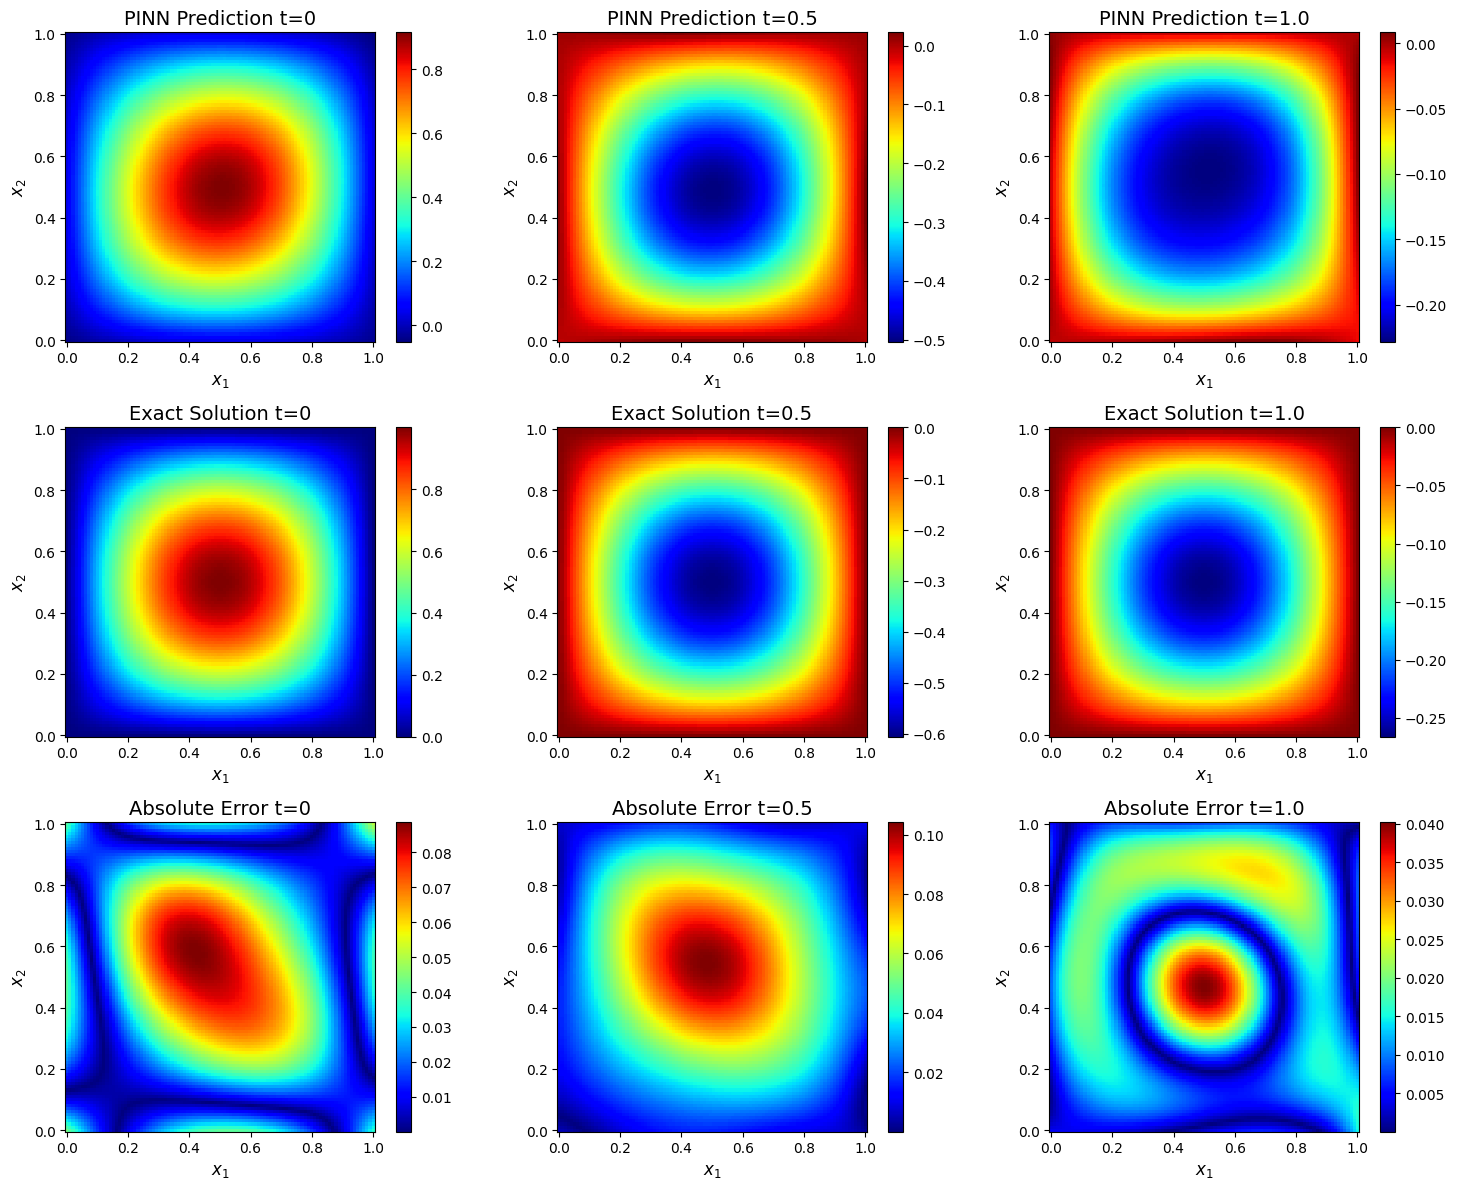

显示了 289 个采样点在 t=0
显示了 289 个采样点在 t=0.5
显示了 289 个采样点在 t=1.0


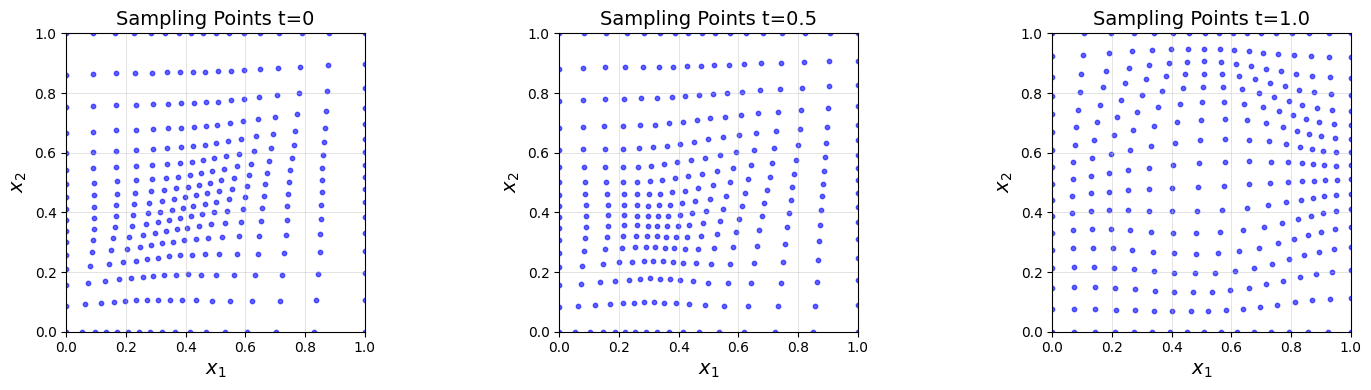


计算最终L2误差...
最终L2误差: 4.286741e-02


In [26]:
# 定义三个关键时间点
time_values = [0.0, 0.5, 1.0]
time_labels = ['t=0', 't=0.5', 't=1.0']

# 创建网格
x_grid = np.linspace(0, Lx, 100)
y_grid = np.linspace(0, Ly, 100)
X, Y = np.meshgrid(x_grid, y_grid)

# 创建3x3子图
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# 为每个时间点生成数据
for time_idx, (t_val, t_label) in enumerate(zip(time_values, time_labels)):
    print(f"Processing {t_label}: t = {t_val:.4f}")
    
    # 准备输入张量
    t_tensor = torch.full((X.size, 1), t_val, dtype=torch.float32, device=device)
    x_tensor = torch.tensor(X.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
    y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
    
    # PINN预测
    with torch.no_grad():
        inputs = torch.cat((t_tensor, x_tensor, y_tensor), dim=1)
        uv_pred = trained_model(inputs).cpu().numpy()
        u_pred = uv_pred[:, 0].reshape(X.shape)
    
    # 精确解
    u_exact = exact_solution_u(X, Y, t_val)
    
    # 误差
    error_u = np.abs(u_pred - u_exact)
    
    # 第一行：PINN预测
    im1 = axes[0, time_idx].pcolormesh(X, Y, u_pred, cmap='jet', shading='auto')
    axes[0, time_idx].set_title(f'PINN Prediction {t_label}', fontsize=14)
    axes[0, time_idx].set_xlabel('$x_1$', fontsize=12)
    axes[0, time_idx].set_ylabel('$x_2$', fontsize=12)
    axes[0, time_idx].set_aspect('equal')
    plt.colorbar(im1, ax=axes[0, time_idx])
    
    # 第二行：精确解
    im2 = axes[1, time_idx].pcolormesh(X, Y, u_exact, cmap='jet', shading='auto')
    axes[1, time_idx].set_title(f'Exact Solution {t_label}', fontsize=14)
    axes[1, time_idx].set_xlabel('$x_1$', fontsize=12)
    axes[1, time_idx].set_ylabel('$x_2$', fontsize=12)
    axes[1, time_idx].set_aspect('equal')
    plt.colorbar(im2, ax=axes[1, time_idx])
    
    # 第三行：误差
    im3 = axes[2, time_idx].pcolormesh(X, Y, error_u, cmap='jet', shading='auto')
    axes[2, time_idx].set_title(f'Absolute Error {t_label}', fontsize=14)
    axes[2, time_idx].set_xlabel('$x_1$', fontsize=12)
    axes[2, time_idx].set_ylabel('$x_2$', fontsize=12)
    axes[2, time_idx].set_aspect('equal')
    plt.colorbar(im3, ax=axes[2, time_idx])
    
    # 输出误差统计
    print(f"Max |u error| at {t_label}: {np.max(error_u):.6e}")
    print(f"Mean |u error| at {t_label}: {np.mean(error_u):.6e}")

plt.tight_layout()
plt.show()

################################################################################
# 采样点可视化（3个时间点的采样点分布）
################################################################################

# 提取采样点数据
t_coll, x_coll, y_coll = collocation_pts
t_coll_np = t_coll.detach().cpu().numpy()
x_coll_np = x_coll.detach().cpu().numpy()
y_coll_np = y_coll.detach().cpu().numpy()

# 创建1x3子图显示采样点分布
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for time_idx, (t_val, t_label) in enumerate(zip(time_values, time_labels)):
    # 选择接近指定时间的点
    time_tolerance = T / 20
    time_mask = np.abs(t_coll_np.flatten() - t_val) < time_tolerance
    
    if np.sum(time_mask) > 10:
        # 获取该时间点附近的采样点
        x_points = x_coll_np[time_mask]
        y_points = y_coll_np[time_mask]
        
        # 随机采样以避免图像过于密集
        if len(x_points) > 1000:
            indices = np.random.choice(len(x_points), 1000, replace=False)
            x_display = x_points[indices]
            y_display = y_points[indices]
        else:
            x_display = x_points
            y_display = y_points
        
        # 绘制采样点
        axes[time_idx].scatter(x_display, y_display, c='blue', s=10, alpha=0.6)
        axes[time_idx].set_xlim(0, Lx)
        axes[time_idx].set_ylim(0, Ly)
        axes[time_idx].set_xlabel('$x_1$', fontsize=14)
        axes[time_idx].set_ylabel('$x_2$', fontsize=14)
        axes[time_idx].set_title(f'Sampling Points {t_label}', fontsize=14)
        axes[time_idx].grid(True, alpha=0.5, linestyle='-', linewidth=0.5)
        axes[time_idx].set_aspect('equal')
        
        print(f"显示了 {len(x_display)} 个采样点在 {t_label}")
    else:
        axes[time_idx].text(0.5, 0.5, f'No points\nnear {t_label}', 
                           ha='center', va='center', transform=axes[time_idx].transAxes)
        axes[time_idx].set_xlim(0, Lx)
        axes[time_idx].set_ylim(0, Ly)
        axes[time_idx].set_xlabel('$x_1$', fontsize=14)
        axes[time_idx].set_ylabel('$x_2$', fontsize=14)
        axes[time_idx].set_title(f'Sampling Points {t_label}', fontsize=14)
        print(f"{t_label}: 采样点数量不足 (只有 {np.sum(time_mask)} 个点)")

plt.tight_layout()
plt.show()

################################################################################
# 计算并输出L2误差
################################################################################
print("\n" + "="*50)
print("计算最终L2误差...")

# 生成测试点
n_test_points = 8000
n_per_dim = int(np.cbrt(n_test_points))

t_test = torch.linspace(0, T, n_per_dim)
x_test = torch.linspace(0, Lx, n_per_dim)
y_test = torch.linspace(0, Ly, n_per_dim)

T_test, X_test, Y_test = torch.meshgrid(t_test, x_test, y_test, indexing='ij')
t_flat = T_test.reshape(-1, 1)
x_flat = X_test.reshape(-1, 1)
y_flat = Y_test.reshape(-1, 1)

txy_test = torch.cat([t_flat, x_flat, y_flat], dim=1).to(device)

# 获取模型预测
with torch.no_grad():
    outputs = trained_model(txy_test)
    u_pred = outputs[:, 0:1]  # 只取u分量

# 计算解析解
t_np = t_flat.cpu().numpy()
x_np = x_flat.cpu().numpy()
y_np = y_flat.cpu().numpy()
u_exact = exact_solution_u(x_np, y_np, t_np)
u_exact_tensor = torch.tensor(u_exact, dtype=torch.float32).to(device)

# 计算L2误差
l2_error = torch.sqrt(torch.mean((u_pred - u_exact_tensor)**2))

print(f"最终L2误差: {l2_error.item():.6e}")
print("="*50)